# 04 - Physics-informed latent simulator

This notebook runs the physics-informed latent simulator directly. Shared model code and reusable metric functions live in `src/lss`, but the actual experiment setup, training call, rollout evaluation, and plotting are kept here.

In [8]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd().resolve()
while not (ROOT / 'src').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
for path in (ROOT, ROOT / 'src'):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

from lss.latent.experiment import (
    evaluate_rollout_horizons,
    rollout_metrics,
    run_latent_experiment,
    seed_everything,
)
from lss.utils import resolve_device

pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 180)
ROOT

PosixPath('/home/alexz/Documents/course_project')

## Configuration

The autoencoder is trained with reconstruction loss and then frozen. The latent simulator is second-order: it receives `[z_current, z_current - z_previous, graph_context]`, predicts `dz`, and rolls forward with `z_next = z_current + dz`. The main dynamics loss is supervised next-frame position MSE after decoding. Physics is now a regularizer, not the full training objective: it discourages excessive spring stretch, non-inertial jumps, box violations, and boundary/driven-node violations if those graph fields exist.

In [9]:
SEED = 20260705
FORCE_TRAIN = False
DEVICE = resolve_device('auto')

DATASET_PATH = ROOT / 'data' / 'depablo-10k-mix-temp.pt'
OUTPUT_DIR = ROOT / 'notebooks' / 'results' / '04_physics_informed_latent'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# These trajectories contain 200 frames indexed 0..199.
ROLLOUT_HORIZONS = [50, 100, 150, 199]

CFG = {
    'dataset_name': 'depablo_mixed_temp',
    'split_seed': 20260623,
    'split_stratify_temperature': False,
    'min_train_p_ratio': None,
    'device': str(DEVICE),
    'pos_dim': 2,
    'batch_graphs': 4,
    'frame_skip': 1,
    'train_frame_start_order': 0,
    'latent_dim': 2,
    'latent_tokens': 32,
    'hidden_size': 96,
    'autoencoder_model': 'attention',
    'edge_feature_dim': 12,
    'ae_max_train_frames_per_sim': 100,
    'dyn_max_train_transitions_per_sim': 100,
    'ae_target_mode': 'normalized_delta',
    'node_feature_mode': 'normalized_delta',
    'ae_max_epochs': 60,
    'ae_patience': 6,
    'ae_lr': 5e-5,
    'ae_weight_decay': 1e-5,
    'dyn_max_epochs': 60,
    'dyn_patience': 6,
    'dyn_lr': 3e-5,
    'dyn_weight_decay': 1e-4,
    'propagator_use_static_context': True,
    'graph_context_dim': 16,
    'propagator_context_include_temperature': False,
    'propagator_step_stride': 1,
    'initial_velocity': 'observed',
    'early_stop_min_delta': 1e-5,
    'rollout_steps_grid': ROLLOUT_HORIZONS,
    'rollout_eval_max_sims_per_split': 20,
    'temperature_pratio_window': 'full',
    'temperature_pratio_estimator': 'robust',
    'temperature_pratio_min_fit_frames': 8,
    'temperature_pratio_min_driven_strain_range': 1e-3,
    'temperature_pratio_smooth_window': 5,
    'should_rollout': True,
    'should_train_propagator': True,
    'force_train': FORCE_TRAIN,
    'cache_path': str(OUTPUT_DIR / 'model_velocity_physreg.pt'),
    'propagator_objective': 'velocity',
    'propagator_model': 'velocity_mlp',
    'propagator_loss': 'delta',
    'propagator_standardize_latent': False,
    'model_seed': SEED,
    'repeat_idx': 1,
    'physics_loss_enabled': True,
    # Physics is a regularizer. Position MSE is the main supervised anchor.
    'physics_lambda': 1e-3,
    'physics_mse_lambda': 1.0,
    'physics_inertial_weight': 1.0,
    'physics_spring_weight': 1.0,
    'physics_spring_strain_margin': 0.25,
    'physics_boundary_weight': 10.0,
    'physics_box_weight': 10.0,
    'physics_latent_noise_std': 0.05,
    'physics_dt': 1.0,
    'physics_default_mass': 1.0,
    'physics_normalize_by_speed': True,
}

SOURCE = {
    'dataset_name': 'depablo_mixed_temp',
    'source_name': 'dePablo mixed temperature',
    'label': 'dePablo mixed temperature physics-informed latent',
    'path': str(DATASET_PATH),
    'dataset_mixture': [
        {
            'name': 'depablo_mixed_temp',
            'label': 'dePablo mixed temperature',
            'path': str(DATASET_PATH),
            'train_count': 20,
            'holdout_train_count': 20,
            'val_count': 20,
        }
    ],
    'target_mode': 'normalized_delta',
    'ae_target_mode': 'normalized_delta',
    'node_feature_mode': 'normalized_delta',
    'latent_dim': 2,
    'repeat_idx': 1,
    'model_seed': SEED,
    'latent_tokens': 32,
    'hidden_size': 96,
    'autoencoder_model': 'attention',
    'edge_feature_dim': 12,
    'ae_max_train_frames_per_sim': 100,
    'dyn_max_train_transitions_per_sim': 100,
    'ae_max_epochs': 60,
    'ae_patience': 6,
    'ae_lr': 5e-5,
    'ae_weight_decay': 1e-5,
    'dyn_max_epochs': 60,
    'dyn_patience': 6,
    'dyn_lr': 3e-5,
    'dyn_weight_decay': 1e-4,
}

display(pd.DataFrame([{
    'device': str(DEVICE),
    'train_networks': SOURCE['dataset_mixture'][0]['train_count'],
    'val_networks': SOURCE['dataset_mixture'][0]['val_count'],
    'latent_dim': CFG['latent_dim'],
    'objective': CFG['propagator_objective'],
    'model': CFG['propagator_model'],
    'physics_mse_lambda': CFG['physics_mse_lambda'],
    'speed_normalized': CFG['physics_normalize_by_speed'],
    'latent_noise_std': CFG['physics_latent_noise_std'],
}]))

,device,train_networks,val_networks,latent_dim,objective,model,physics_mse_lambda,speed_normalized,latent_noise_std
0,cuda,20,20,2,velocity,velocity_mlp,1.0,True,0.05


## Train / load model

In [10]:
seed_everything(SEED)
result = run_latent_experiment(SOURCE, CFG, device=DEVICE)

history = result['dyn_history'].copy()
history.to_csv(OUTPUT_DIR / 'training_history.csv', index=False)

display(history.tail(10))

loading cached latent experiment: /home/alexz/Documents/course_project/notebooks/results/04_physics_informed_latent/model_velocity_physreg.pt


,epoch,train_loss,val_loss,train_dz_mse_norm,train_loss_raw,train_physical,train_inertial,train_spring,train_external,train_boundary,train_box,train_previous_speed,train_position_mse,train_latent_supervised,val_dz_mse_norm,val_dz_mse_raw,val_physical,val_inertial,val_spring,val_external,val_boundary,val_box,val_previous_speed,val_position_mse,val_latent_supervised,dataset,latent_dim,target_mode,hidden_size,propagator_loss,propagator_objective,propagator_multistep_horizons,propagator_multistep_loss,propagator_step_stride,initial_velocity
0,1,0.000005,0.000066,0.000005,0.243155,0.001644,0.000012,0.0,0.0,0.0,1.219708e-07,0.002981,0.000004,0.243155,0.000066,0.265445,0.061659,0.002041,0.0,0.0,0.0,2.449191e-07,0.026226,0.000004,0.265445,dePablo mixed temperature physics-informed latent,2,normalized_delta,96,delta,velocity,,final_horizon,1,observed
1,2,0.000005,0.000066,0.000005,0.248234,0.001555,0.000012,0.0,0.0,0.0,1.252679e-07,0.003008,0.000004,0.248234,0.000066,0.269322,0.061639,0.002040,0.0,0.0,0.0,2.486573e-07,0.026226,0.000004,0.269322,dePablo mixed temperature physics-informed latent,2,normalized_delta,96,delta,velocity,,final_horizon,1,observed
2,3,0.000005,0.000066,0.000005,0.250266,0.001444,0.000011,0.0,0.0,0.0,1.273791e-07,0.002948,0.000004,0.250266,0.000066,0.274635,0.061539,0.002039,0.0,0.0,0.0,2.249933e-07,0.026226,0.000004,0.274635,dePablo mixed temperature physics-informed latent,2,normalized_delta,96,delta,velocity,,final_horizon,1,observed
3,4,0.000005,0.000066,0.000005,0.262057,0.001363,0.000010,0.0,0.0,0.0,1.257333e-07,0.003005,0.000004,0.262057,0.000066,0.282682,0.061521,0.002038,0.0,0.0,0.0,2.279142e-07,0.026226,0.000004,0.282682,dePablo mixed temperature physics-informed latent,2,normalized_delta,96,delta,velocity,,final_horizon,1,observed
4,5,0.000005,0.000066,0.000005,0.267591,0.001202,0.000009,0.0,0.0,0.0,1.270630e-07,0.002970,0.000004,0.267591,0.000066,0.294859,0.061448,0.002037,0.0,0.0,0.0,2.213423e-07,0.026226,0.000004,0.294859,dePablo mixed temperature physics-informed latent,2,normalized_delta,96,delta,velocity,,final_horizon,1,observed
5,6,0.000005,0.000066,0.000005,0.283277,0.001084,0.000008,0.0,0.0,0.0,1.291177e-07,0.002994,0.000004,0.283277,0.000066,0.310872,0.061428,0.002036,0.0,0.0,0.0,2.242539e-07,0.026226,0.000004,0.310872,dePablo mixed temperature physics-informed latent,2,normalized_delta,96,delta,velocity,,final_horizon,1,observed
6,7,0.000005,0.000066,0.000005,0.309841,0.000960,0.000006,0.0,0.0,0.0,1.479941e-07,0.002976,0.000004,0.309841,0.000066,0.331234,0.061379,0.002035,0.0,0.0,0.0,2.148134e-07,0.026226,0.000004,0.331234,dePablo mixed temperature physics-informed latent,2,normalized_delta,96,delta,velocity,,final_horizon,1,observed


## Evaluate all test networks

`run_latent_experiment` evaluates a small rollout subset during training. Here we explicitly evaluate all test networks in chunks and save the full table.

In [11]:
rollout_parts = []
for start in range(0, len(result['test_data']), 20):
    sims = result['test_data'][start:start + 20]
    raw, _ = evaluate_rollout_horizons(
        result['ae'],
        result['dyn'],
        sims,
        result['latent_stats'],
        cfg=result['params'],
        normalizers=result['normalizers'],
        dataset=result['label'],
        split_name='test',
        rollout_steps=ROLLOUT_HORIZONS,
        device=DEVICE,
    )
    raw = raw.copy()
    raw['sim_idx'] += start
    rollout_parts.append(raw)
    print(f'evaluated {start + len(sims)}/{len(result["test_data"])}', flush=True)

rollout_rows = pd.concat(rollout_parts, ignore_index=True)
rollout_rows.to_csv(OUTPUT_DIR / 'all_test_rollout_rows.csv', index=False)
rollout_rows.head()

evaluated 20/260
evaluated 40/260
evaluated 60/260
evaluated 80/260
evaluated 100/260
evaluated 120/260
evaluated 140/260
evaluated 160/260
evaluated 180/260
evaluated 200/260
evaluated 220/260
evaluated 240/260
evaluated 260/260


,dataset,split,sim_idx,source,target_index,rollout_steps,filtered_steps,temperature,rho_scale_mode,rho_scale,pred_p_ratio,true_p_ratio,final_pos_mse,initial_to_target_mse,pred_to_initial_mse,movement_fraction_mse,rollout_error_fraction,rollout_position_r2
0,dePablo mixed temperature physics-informed latent,test,0,depablo_mixed_temp,50,50,50,0.1,none,NaN,0.500415,0.011876,0.000663,0.000892,0.000141,0.157498,0.743303,0.256697
1,dePablo mixed temperature physics-informed latent,test,0,depablo_mixed_temp,100,100,100,0.1,none,NaN,0.348656,0.009191,0.004654,0.003515,0.002337,0.664781,1.323947,0.000000
2,dePablo mixed temperature physics-informed latent,test,0,depablo_mixed_temp,150,150,150,0.1,none,NaN,0.501696,-0.000574,0.013676,0.008005,0.009886,1.235030,1.708455,0.000000
3,dePablo mixed temperature physics-informed latent,test,0,depablo_mixed_temp,199,199,199,0.1,none,NaN,0.713736,-0.007743,0.025140,0.014156,0.021888,1.546161,1.775847,0.000000
4,dePablo mixed temperature physics-informed latent,test,1,depablo_mixed_temp,50,50,50,5.0,none,NaN,0.766222,-0.638827,0.001249,0.001584,0.000359,0.226451,0.788310,0.211690


## Rollout summary

In [12]:
metric_rows = []
for horizon, group in rollout_rows.groupby('rollout_steps', sort=True):
    metric_rows.append(
        rollout_metrics(
            group,
            dataset=result['label'],
            split_name='test',
            rollout_steps=int(horizon),
        )
    )

metrics = pd.DataFrame(metric_rows).sort_values('rollout_steps')
metrics.to_csv(OUTPUT_DIR / 'rollout_metrics.csv', index=False)
display(metrics[['rollout_steps', 'rollout_position_r2', 'final_pos_mse', 'p_ratio_r2']])

,rollout_steps,rollout_position_r2,final_pos_mse,p_ratio_r2
0,50,0.091426,0.001748,-6.788803
1,100,0.000000,0.005229,-4.505396
2,150,0.000000,0.013475,-4.990445
3,199,0.000000,0.022399,-11.256791


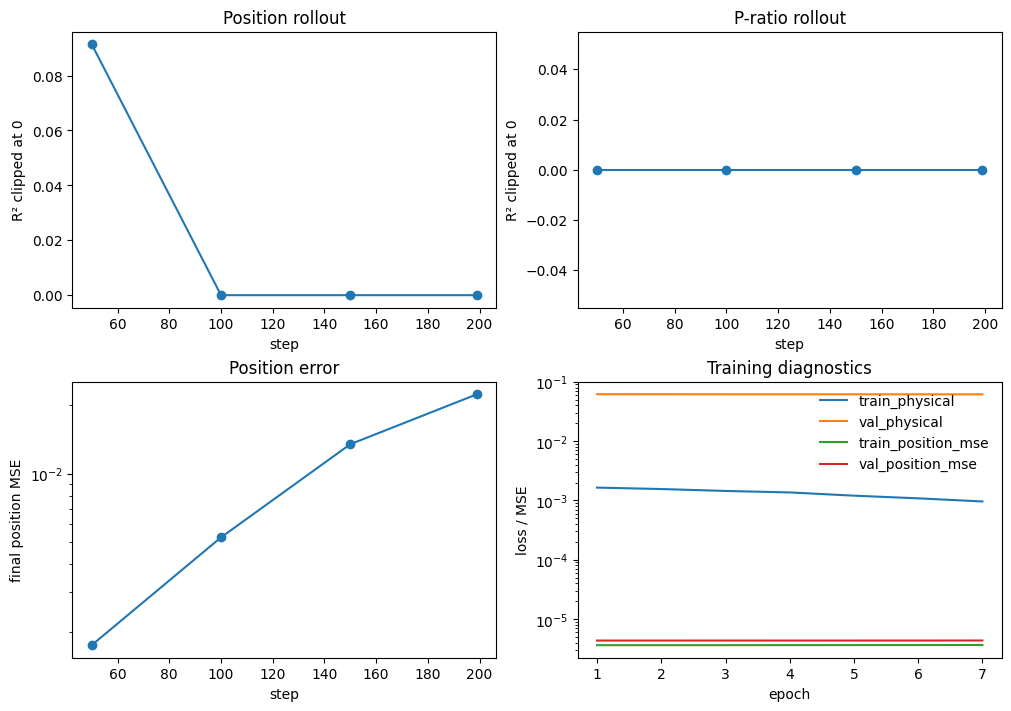

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(10, 7), constrained_layout=True)

axes[0, 0].plot(metrics['rollout_steps'], metrics['rollout_position_r2'].clip(lower=0), 'o-')
axes[0, 0].set(title='Position rollout', xlabel='step', ylabel='R² clipped at 0')

axes[0, 1].plot(metrics['rollout_steps'], metrics['p_ratio_r2'].clip(lower=0), 'o-')
axes[0, 1].set(title='P-ratio rollout', xlabel='step', ylabel='R² clipped at 0')

axes[1, 0].plot(metrics['rollout_steps'], metrics['final_pos_mse'], 'o-')
axes[1, 0].set(title='Position error', xlabel='step', ylabel='final position MSE')
axes[1, 0].set_yscale('log')

plot_cols = [col for col in ['train_physical', 'val_physical', 'train_position_mse', 'val_position_mse'] if col in history.columns]
for col in plot_cols:
    axes[1, 1].plot(history['epoch'], history[col], label=col)
axes[1, 1].set(title='Training diagnostics', xlabel='epoch', ylabel='loss / MSE')
axes[1, 1].set_yscale('log')
axes[1, 1].legend(frameon=False)

fig.savefig(OUTPUT_DIR / 'physics_only_summary.png', dpi=220)
plt.show()

## Final p-ratio scatter

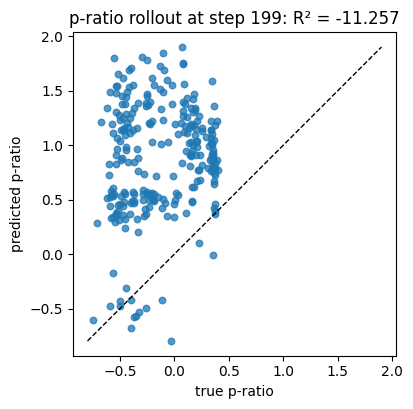

In [14]:
horizon = int(rollout_rows['rollout_steps'].max())
scatter = rollout_rows[rollout_rows['rollout_steps'].eq(horizon)].dropna(subset=['true_p_ratio', 'pred_p_ratio'])
true = scatter['true_p_ratio'].to_numpy()
pred = scatter['pred_p_ratio'].to_numpy()
denom = np.sum((true - true.mean()) ** 2)
r2 = np.nan if denom == 0 else 1.0 - np.sum((pred - true) ** 2) / denom

fig, ax = plt.subplots(figsize=(4.5, 4.2))
ax.scatter(true, pred, s=22, alpha=0.75)
lo = min(true.min(), pred.min())
hi = max(true.max(), pred.max())
ax.plot([lo, hi], [lo, hi], color='black', lw=1, ls='--')
ax.set_xlabel('true p-ratio')
ax.set_ylabel('predicted p-ratio')
ax.set_title(f'p-ratio rollout at step {horizon}: R² = {r2:.3f}')
ax.set_aspect('equal', adjustable='box')
plt.show()

## Current limitation

The current physics term is a regularizer, not a complete simulator. It includes inertial consistency, excessive spring-stretch penalty with a margin, box-violation penalty, and optional boundary/driven-node penalties if graph fields exist. The dePablo mixed-temperature graphs currently expose `x`, `edge_index`, `edge_attr`, `box`, `temperature`, and `time`, but no explicit damping, thermostat, stochastic-force, or driven-boundary fields. The supervised MSE term is therefore needed to learn the unknown forcing/noise.